C:\Users\LALITH\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8217 - loss: 0.6775 - val_accuracy: 0.9072 - val_loss: 0.3336
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9084 - loss: 0.3200 - val_accuracy: 0.9235 - val_loss: 0.2725
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9230 - loss: 0.2687 - val_accuracy: 0.9323 - val_loss: 0.2398
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9326 - loss: 0.2350 - val_accuracy: 0.9379 - val_loss: 0.2155
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9398 - loss: 0.2083 - val_accuracy: 0.9427 - val_loss: 0.2000
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9207 - loss: 0.2708 - val_accuracy: 0.9543 - val_loss: 0.1531
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9645 - loss: 0.1188 - val_accuracy: 0.9697 - val_loss: 0.1043
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9757 - loss: 0

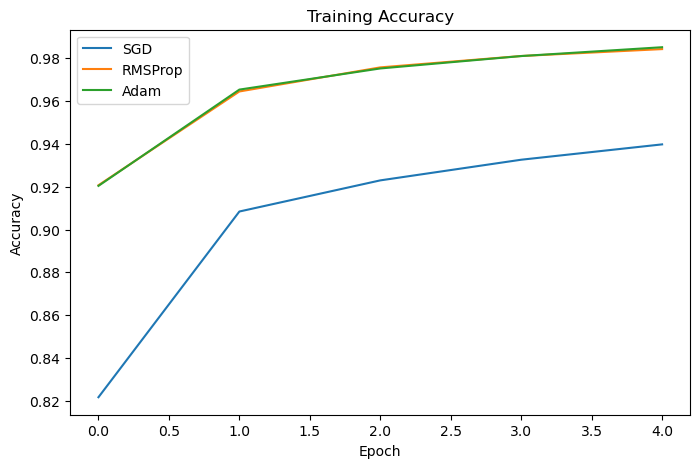

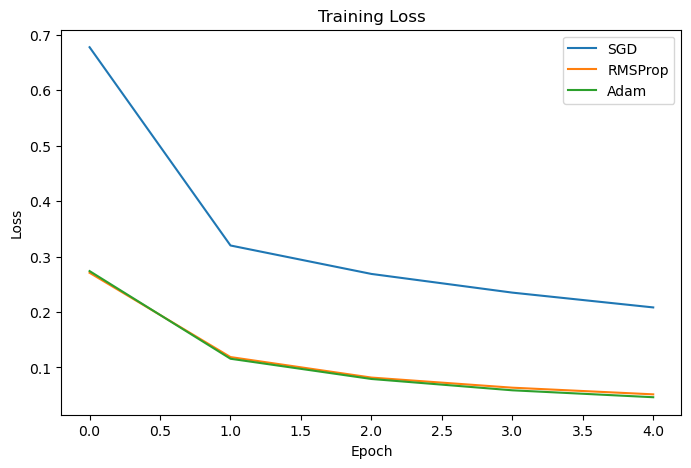


Optimizer Comparison
  Optimizer  Accuracy      Loss
0       SGD    0.9424  0.198353
1   RMSProp    0.9781  0.087856
2      Adam    0.9733  0.089386

Best Optimizer: RMSProp
Highest Accuracy: 0.9781
Lowest Loss: 0.0879

Conclusion:
RMSProp performed the best because it achieved the highest accuracy (0.9781) and the lowest loss (0.0879).


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# Load MNIST Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0

# -------------------------------
# Function to Create Model
# -------------------------------
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# -------------------------------
# Train with SGD
# -------------------------------
model_sgd = create_model()
model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Train with RMSProp
# -------------------------------
model_rms = create_model()
model_rms.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_rms = model_rms.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Train with Adam
# -------------------------------
model_adam = create_model()
model_adam.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Plot Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_rms.history['accuracy'], label='RMSProp')
plt.plot(history_adam.history['accuracy'], label='Adam')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------------
# Plot Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_rms.history['loss'], label='RMSProp')
plt.plot(history_adam.history['loss'], label='Adam')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------------
# Evaluate Models
# -------------------------------
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
rms_loss, rms_acc = model_rms.evaluate(x_test, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

# -------------------------------
# Comparison Table
# -------------------------------
results = pd.DataFrame({
    "Optimizer": ["SGD", "RMSProp", "Adam"],
    "Accuracy": [sgd_acc, rms_acc, adam_acc],
    "Loss": [sgd_loss, rms_loss, adam_loss]
})

print("\nOptimizer Comparison")
print(results)

# -------------------------------
# Best Optimizer
# -------------------------------
best = results.loc[results["Accuracy"].idxmax()]

print("\nBest Optimizer:", best["Optimizer"])
print("Highest Accuracy:", round(best["Accuracy"], 4))
print("Lowest Loss:", round(best["Loss"], 4))

print("\nConclusion:")
print(f"{best['Optimizer']} performed the best because it achieved the highest accuracy ({best['Accuracy']:.4f}) and the lowest loss ({best['Loss']:.4f}).")